# Home Credit Default Risk

This notebook builds and evaluates different to predict loan default risk using the Home Credit Default Risk dataset.

**Objective:** Build a binary classification model to predict whether a loan applicant will default (TARGET=1) or repay (TARGET=0).

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import os
import shap
import time
import xgboost as xgb

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries loaded successfully.")

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.8/101.7 MB 41.3 MB/s eta 0:00:03
   --- ------------------------------------ 8.7/101.7 MB 33.4 MB/s eta 0:00:03
   ---- ----------------------------------- 12.1/101.7 MB 25.0 MB/s eta 0:00:04
   ----- ---------------------------------- 14.4/101.7 MB 20.8 MB/s eta 0:00:05
   ------ --------------------------------- 16.3/101.7 MB 17.9 MB/s eta 0:00:05
   ------- -------------------------------- 18.4/101.7 MB 16.4 MB/s eta 0:00:06
   -------- ------------------------------- 20.7/101.7 MB 15.5 MB/s eta 0:00:06
   --------- ------------------------------ 23.1/101.7 MB 15.0 MB/s eta 0:00:06
   ---------- ----------------------------- 26.0/101.7 MB 14.7 MB/s eta 0:00:06
   ----------- ---------------------------- 28.6/101.7 MB 14.4 MB/s eta 0:00:06
   ------------ --------------------------- 30.9/101.7 MB 14.2 MB/s eta 0:00:05
   ------------ --------------------------- 33.0/10

In [53]:
df = pd.read_csv("../dataset/application_train.csv", encoding="latin-1")

In [54]:
# Verify TARGET column and remove SK_ID_CURR
print(f"\nTARGET value counts:")
print(df['TARGET'].value_counts())
print(f"\nTarget variable type: {df['TARGET'].dtype}")
print(f"Missing values in TARGET: {df['TARGET'].isnull().sum()}")

# Remove SK_ID_CURR column (applicant ID - not useful for prediction)
if 'SK_ID_CURR' in df.columns:
    df = df.drop('SK_ID_CURR', axis=1)
    print(f"\n✓ SK_ID_CURR column removed")

print(f"\nDataset shape after removing SK_ID_CURR: {df.shape[0]:,} rows × {df.shape[1]} columns")


TARGET value counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target variable type: int64
Missing values in TARGET: 0

✓ SK_ID_CURR column removed

Dataset shape after removing SK_ID_CURR: 307,511 rows × 121 columns


In [55]:
# Descriptive statistics
print("Descriptive Statistics for Numeric Columns:")
print(df.describe().T.head(10))

Descriptive Statistics for Numeric Columns:
                               count           mean            std  \
TARGET                      307511.0       0.080729       0.272419   
CNT_CHILDREN                307511.0       0.417052       0.722121   
AMT_INCOME_TOTAL            307511.0  168797.919297  237123.146279   
AMT_CREDIT                  307511.0  599025.999706  402490.776996   
AMT_ANNUITY                 307499.0   27108.573909   14493.737315   
AMT_GOODS_PRICE             307233.0  538396.207429  369446.460540   
REGION_POPULATION_RELATIVE  307511.0       0.020868       0.013831   
DAYS_BIRTH                  307511.0  -16036.995067    4363.988632   
DAYS_EMPLOYED               307511.0   63815.045904  141275.766519   
DAYS_REGISTRATION           307511.0   -4986.120328    3522.886321   

                                    min            25%           50%  \
TARGET                          0.00000       0.000000       0.00000   
CNT_CHILDREN                    0.00000  

In [56]:
y = df['TARGET']
X = df.drop('TARGET', axis=1)

## Handle Missing Values and Preprocessing

In [57]:
# Handle missing values for numeric columns (impute with median)
numeric_cols = X.select_dtypes(include=[np.number]).columns
print(f"Numeric columns with missing values:")
numeric_missing = X[numeric_cols].isnull().sum()
print(numeric_missing[numeric_missing > 0].head(10))

# Impute numeric columns with median
imputer_numeric = SimpleImputer(strategy='median')
X[numeric_cols] = imputer_numeric.fit_transform(X[numeric_cols])
print(f"\n✓ Numeric columns imputed with median")

# Handle missing values for categorical columns (impute with mode)
categorical_cols = X.select_dtypes(include='object').columns
if len(categorical_cols) > 0:
    print(f"\nCategorical columns with missing values:")
    cat_missing = X[categorical_cols].isnull().sum()
    print(cat_missing[cat_missing > 0].head(10))
    
    # Impute categorical columns with mode
    imputer_cat = SimpleImputer(strategy='most_frequent')
    X[categorical_cols] = imputer_cat.fit_transform(X[categorical_cols])
    print(f"\n✓ Categorical columns imputed with mode")
else:
    print(f"\nNo categorical columns to impute")

print(f"\nMissing values remaining: {X.isnull().sum().sum()}")

Numeric columns with missing values:
AMT_ANNUITY                        12
AMT_GOODS_PRICE                   278
OWN_CAR_AGE                    202929
CNT_FAM_MEMBERS                     2
EXT_SOURCE_1                   173378
EXT_SOURCE_2                      660
EXT_SOURCE_3                    60965
APARTMENTS_AVG                 156061
BASEMENTAREA_AVG               179943
YEARS_BEGINEXPLUATATION_AVG    150007
dtype: int64

✓ Numeric columns imputed with median

Categorical columns with missing values:
NAME_TYPE_SUITE          1292
OCCUPATION_TYPE         96391
FONDKAPREMONT_MODE     210295
HOUSETYPE_MODE         154297
WALLSMATERIAL_MODE     156341
EMERGENCYSTATE_MODE    145755
dtype: int64

✓ Categorical columns imputed with mode

Missing values remaining: 0


In [58]:
# Redefine categorical columns after feature selection
categorical_cols = X.select_dtypes(include='object').columns

# Encode categorical variables using one-hot encoding
print(f"Categorical columns before encoding: {len(categorical_cols)}")
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"Features after one-hot encoding: {X.shape[1]}")

# Clean feature names for LightGBM (remove special JSON characters)
# LightGBM doesn't support special characters like [, ], {, }, :, ", etc.
import re
X.columns = [re.sub(r'[^a-zA-Z0-9_]', '_', str(col)) for col in X.columns]
X.columns = [re.sub(r'_+', '_', col).strip('_') for col in X.columns]

# Handle any duplicate column names after sanitization
cols = list(X.columns)
seen = {}
for i, col in enumerate(cols):
    if col in seen:
        seen[col] += 1
        cols[i] = f"{col}_{seen[col]}"
    else:
        seen[col] = 0
X.columns = cols

print(f"✓ Categorical variables encoded and feature names sanitized")
print(f"Sample feature names: {X.columns[:5].tolist()}")


Categorical columns before encoding: 16
Features after one-hot encoding: 228
✓ Categorical variables encoded and feature names sanitized
Sample feature names: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']


In [59]:
# Scale numerical features (important for logistic regression)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("✓ Features scaled using StandardScaler")
print(f"\nScaled features statistics:")
print(X_scaled.describe().iloc[:, :5])

✓ Features scaled using StandardScaler

Scaled features statistics:
       CNT_CHILDREN  AMT_INCOME_TOTAL    AMT_CREDIT   AMT_ANNUITY  \
count  3.075110e+05      3.075110e+05  3.075110e+05  3.075110e+05   
mean  -4.815343e-17     -1.229253e-17 -4.545000e-17 -1.793045e-17   
std    1.000002e+00      1.000002e+00  1.000002e+00  1.000002e+00   
min   -5.775378e-01     -6.036870e-01 -1.376496e+00 -1.758933e+00   
25%   -5.775378e-01     -2.374210e-01 -8.174760e-01 -7.302952e-01   
50%   -5.775378e-01     -9.129414e-02 -2.124151e-01 -1.521715e-01   
75%    8.072731e-01      1.421293e-01  5.208178e-01  5.166140e-01   
max    2.573387e+01      4.927034e+02  8.574059e+00  1.593252e+01   

       AMT_GOODS_PRICE  
count     3.075110e+05  
mean     -9.150077e-18  
std       1.000002e+00  
min      -1.348042e+00  
25%      -8.118758e-01  
50%      -2.391526e-01  
75%       3.823129e-01  
max       9.509326e+00  


In [60]:
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]:,} ({X_train.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]:,} ({X_test.shape[0]/len(X_scaled)*100:.1f}%)")
print(f"\nTraining set features: {X_train.shape[1]}")
print(f"Testing set features: {X_test.shape[1]}")

print(f"\nTraining set TARGET distribution:")
print(y_train.value_counts())
print(f"\nTesting set TARGET distribution:")
print(y_test.value_counts())

Training set size: 246,008 (80.0%)
Testing set size: 61,503 (20.0%)

Training set features: 228
Testing set features: 228

Training set TARGET distribution:
TARGET
0    226148
1     19860
Name: count, dtype: int64

Testing set TARGET distribution:
TARGET
0    56538
1     4965
Name: count, dtype: int64


# Logistic Regression

In [61]:
# Initialize and train logistic regression model
log_reg = LogisticRegression(class_weight='balanced',max_iter=1000, random_state=42, n_jobs=-1)
log_reg.fit(X_train, y_train)

print("✓ Logistic Regression model trained successfully")
print(f"\nModel parameters:")
print(f"  - Classes: {log_reg.classes_}")
print(f"  - Number of features: {log_reg.n_features_in_}")
print(f"  - Intercept: {log_reg.intercept_[0]:.6f}")

✓ Logistic Regression model trained successfully

Model parameters:
  - Classes: [0 1]
  - Number of features: 228
  - Intercept: -0.371935


In [62]:
# Make predictions on training and testing sets
y_train_pred = log_reg.predict(X_train)
y_test_pred = log_reg.predict(X_test)

# Get prediction probabilities
y_train_pred_proba = log_reg.predict_proba(X_train)[:, 1]
y_test_pred_proba = log_reg.predict_proba(X_test)[:, 1]

print("✓ Predictions generated for both training and testing sets")
print(f"\nTraining predictions distribution:")
print(pd.Series(y_train_pred).value_counts())
print(f"\nTesting predictions distribution:")
print(pd.Series(y_test_pred).value_counts())

✓ Predictions generated for both training and testing sets

Training predictions distribution:
0    162216
1     83792
Name: count, dtype: int64

Testing predictions distribution:
0    40634
1    20869
Name: count, dtype: int64


In [63]:
# Evaluate model performance on test set
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
roc_auc_test = roc_auc_score(y_test, y_test_pred_proba)

print("=" * 70)
print("MODEL PERFORMANCE METRICS (TEST SET)")
print("=" * 70)
print(f"Accuracy:   {accuracy_test:.4f}")
print(f"Precision:  {precision_test:.4f}")
print(f"Recall:     {recall_test:.4f}")
print(f"F1-Score:   {f1_test:.4f}")
print(f"ROC-AUC:    {roc_auc_test:.4f}")
print("=" * 70)

# Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(cm_test)

# Classification Report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Repay (0)', 'Default (1)']))

MODEL PERFORMANCE METRICS (TEST SET)
Accuracy:   0.6896
Precision:  0.1616
Recall:     0.6794
F1-Score:   0.2611
ROC-AUC:    0.7485

Confusion Matrix:
[[39042 17496]
 [ 1592  3373]]

Detailed Classification Report:
              precision    recall  f1-score   support

   Repay (0)       0.96      0.69      0.80     56538
 Default (1)       0.16      0.68      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



In [64]:
# Compare training vs test performance
print("\n" + "=" * 70)
print("TRAINING vs TEST SET COMPARISON")
print("=" * 70)

metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Training Set': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        roc_auc_score(y_train, y_train_pred_proba)
    ],
    'Testing Set': [accuracy_test, precision_test, recall_test, f1_test, roc_auc_test]
})

metrics_comparison['Difference'] = metrics_comparison['Training Set'] - metrics_comparison['Testing Set']
print(metrics_comparison.to_string(index=False))


TRAINING vs TEST SET COMPARISON
   Metric  Training Set  Testing Set  Difference
 Accuracy      0.688514     0.689641   -0.001127
Precision      0.161256     0.161627   -0.000371
   Recall      0.680363     0.679355    0.001007
 F1-Score      0.260719     0.261129   -0.000410
  ROC-AUC      0.749201     0.748496    0.000705


## Feature Importance Analysis for LR

In [65]:
# Extract feature coefficients from logistic regression
feature_importance = pd.DataFrame({
    'Feature': X_scaled.columns,
    'Coefficient': log_reg.coef_[0]
})

# Sort by absolute coefficient value
feature_importance['Abs_Coefficient'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print("Top 20 Most Important Features (by Coefficient Magnitude):")
print(feature_importance.head(20).to_string(index=False))

Top 20 Most Important Features (by Coefficient Magnitude):
                                        Feature  Coefficient  Abs_Coefficient
                                  DAYS_EMPLOYED     7.693939         7.693939
                     NAME_INCOME_TYPE_Pensioner    -3.116963         3.116963
                          ORGANIZATION_TYPE_XNA    -2.712799         2.712799
NAME_EDUCATION_TYPE_Secondary_secondary_special     1.624162         1.624162
           NAME_EDUCATION_TYPE_Higher_education     1.413825         1.413825
                       NAME_INCOME_TYPE_Working     1.366850         1.366850
          NAME_INCOME_TYPE_Commercial_associate     1.129215         1.129215
                                AMT_GOODS_PRICE    -0.960203         0.960203
                                 FLAG_EMP_PHONE     0.933691         0.933691
                                     AMT_CREDIT     0.898612         0.898612
                 NAME_INCOME_TYPE_State_servant     0.680694         0.680694
     

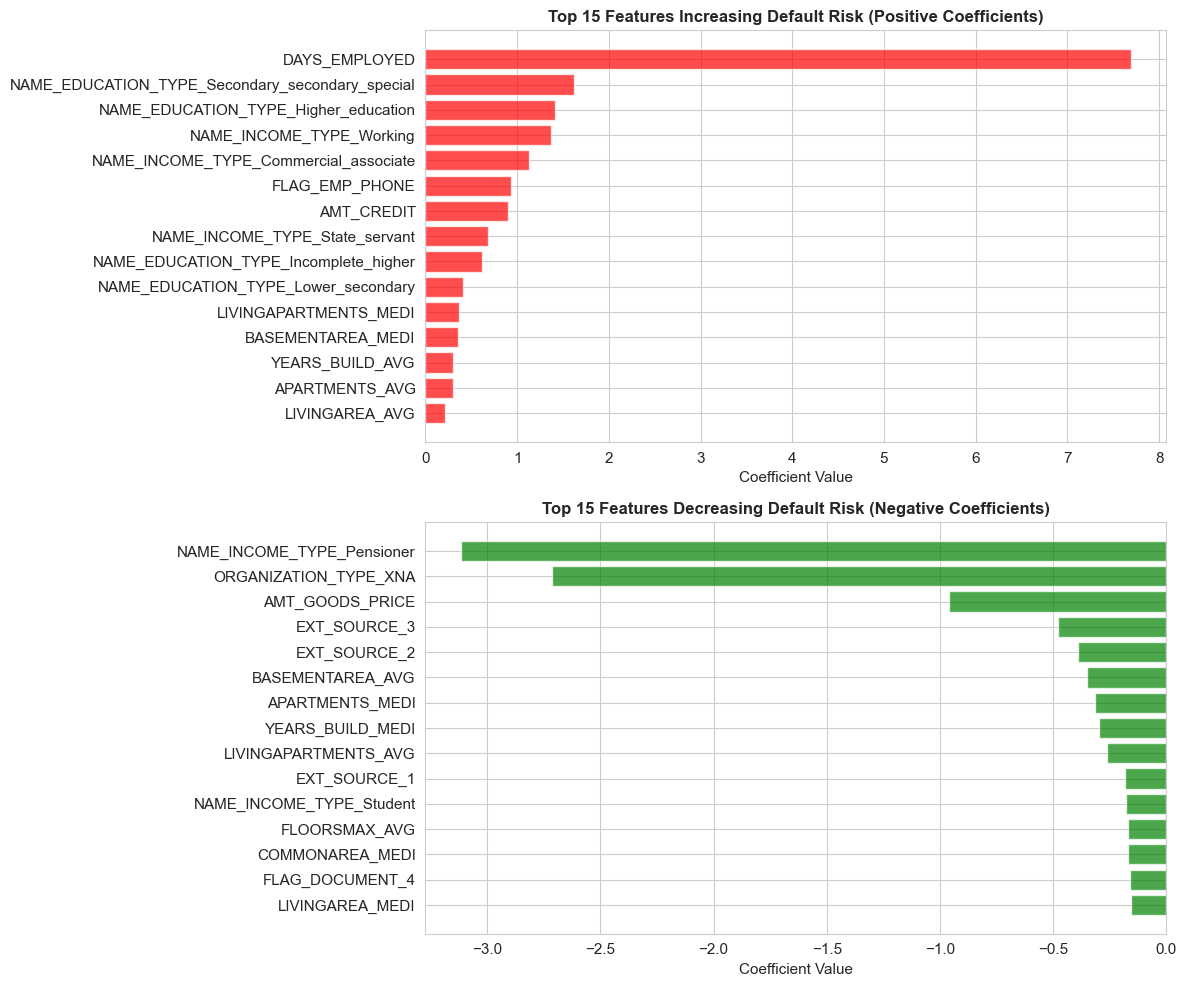

In [66]:
# Visualize top features
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top 15 positive coefficients (increase default risk)
top_positive = feature_importance[feature_importance['Coefficient'] > 0].head(15)
axes[0].barh(range(len(top_positive)), top_positive['Coefficient'].values, color='red', alpha=0.7)
axes[0].set_yticks(range(len(top_positive)))
axes[0].set_yticklabels(top_positive['Feature'].values)
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Top 15 Features Increasing Default Risk (Positive Coefficients)', 
                  fontsize=12, fontweight='bold')
axes[0].invert_yaxis()

# Top 15 negative coefficients (decrease default risk)
top_negative = feature_importance[feature_importance['Coefficient'] < 0].head(15)
axes[1].barh(range(len(top_negative)), top_negative['Coefficient'].values, color='green', alpha=0.7)
axes[1].set_yticks(range(len(top_negative)))
axes[1].set_yticklabels(top_negative['Feature'].values)
axes[1].set_xlabel('Coefficient Value')
axes[1].set_title('Top 15 Features Decreasing Default Risk (Negative Coefficients)', 
                  fontsize=12, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

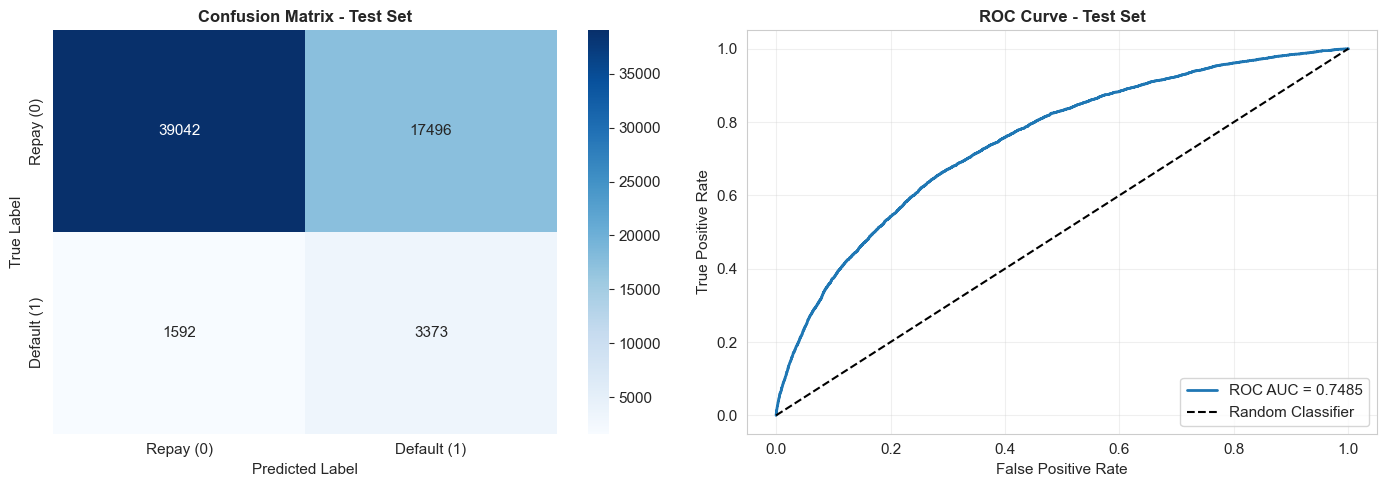

In [67]:
# Visualize Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Repay (0)', 'Default (1)'],
            yticklabels=['Repay (0)', 'Default (1)'])
axes[0].set_title('Confusion Matrix - Test Set', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc_test:.4f}', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Test Set', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## SHAP values for LR

In [68]:
# Create SHAP explainer for the tuned logistic regression model
# Use a sample of the training data for faster computation
sample_size = min(5000, X_train.shape[0])  # Use up to 5000 samples for background
X_train_sample = X_train.sample(n=sample_size, random_state=42)

print(f"Creating SHAP explainer with {sample_size} background samples...")
explainer = shap.LinearExplainer(log_reg, X_train_sample)
print("✓ SHAP explainer created successfully")

Creating SHAP explainer with 5000 background samples...
✓ SHAP explainer created successfully


In [69]:
# Calculate SHAP values for the test set
print("Calculating SHAP values for test set (this may take a moment)...")
shap_values_test = explainer.shap_values(X_test)
print("✓ SHAP values calculated successfully")

print(f"\nSHAP values shape: {shap_values_test.shape}")
print(f"Expected shape (test samples × features): {X_test.shape}")

Calculating SHAP values for test set (this may take a moment)...
✓ SHAP values calculated successfully

SHAP values shape: (61503, 228)
Expected shape (test samples × features): (61503, 228)


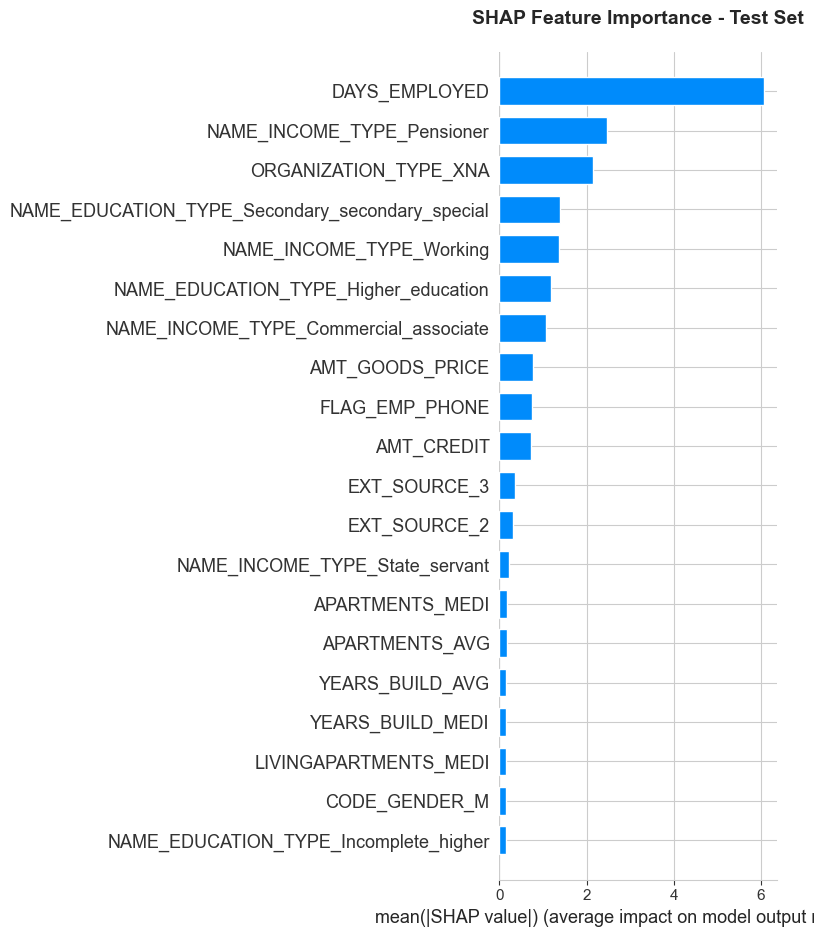

✓ SHAP summary plot (bar) generated


In [70]:
# SHAP Summary Plot (Bar) - shows feature importance based on SHAP values
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_test, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Test Set', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ SHAP summary plot (bar) generated")

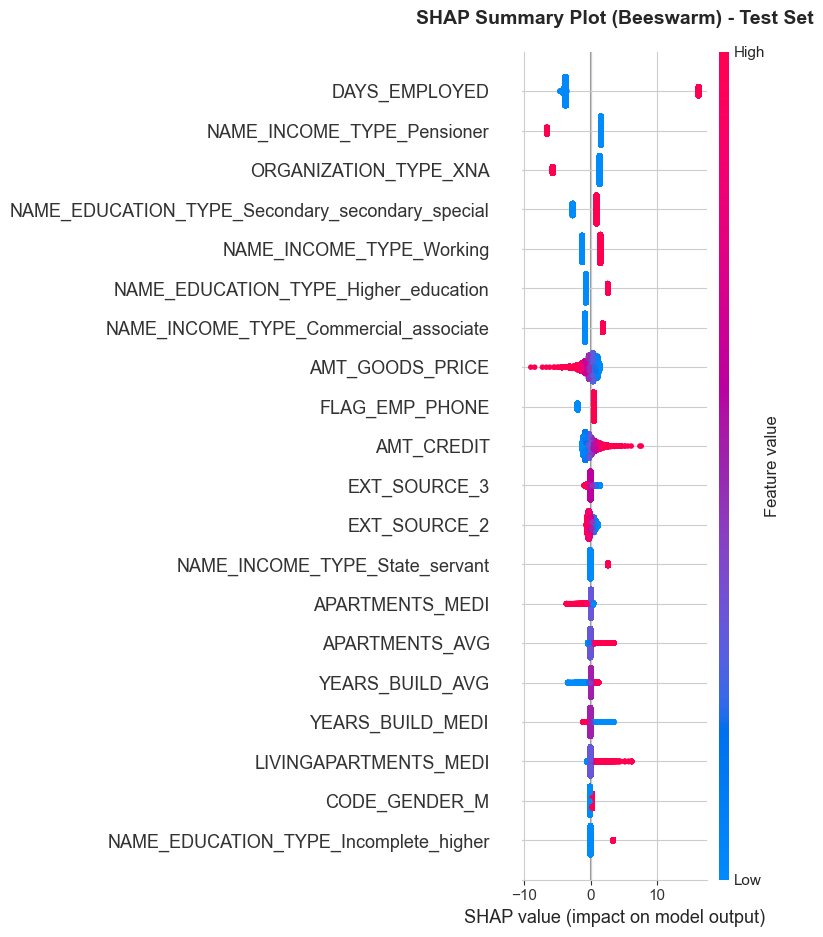

✓ SHAP summary plot (beeswarm) generated


In [71]:
# SHAP Summary Plot (Beeswarm) - shows the impact of each feature on model output
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_test, X_test, show=False)
plt.title('SHAP Summary Plot (Beeswarm) - Test Set', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ SHAP summary plot (beeswarm) generated")

In [72]:
# Analyze SHAP values - top features
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_test).mean(axis=0)
})
shap_importance = shap_importance.sort_values('Mean_Abs_SHAP', ascending=False)

print("Top 15 Most Important Features (by Mean Absolute SHAP values):")
print(shap_importance.head(15).to_string(index=False))

Top 15 Most Important Features (by Mean Absolute SHAP values):
                                        Feature  Mean_Abs_SHAP
                                  DAYS_EMPLOYED       6.068592
                     NAME_INCOME_TYPE_Pensioner       2.459624
                          ORGANIZATION_TYPE_XNA       2.140727
NAME_EDUCATION_TYPE_Secondary_secondary_special       1.400406
                       NAME_INCOME_TYPE_Working       1.370192
           NAME_EDUCATION_TYPE_Higher_education       1.176534
          NAME_INCOME_TYPE_Commercial_associate       1.079220
                                AMT_GOODS_PRICE       0.779150
                                 FLAG_EMP_PHONE       0.736758
                                     AMT_CREDIT       0.727988
                                   EXT_SOURCE_3       0.362391
                                   EXT_SOURCE_2       0.321382
                 NAME_INCOME_TYPE_State_servant       0.226770
                                APARTMENTS_MEDI       0

## Random Forest

In [73]:
# Initialize and train Random Forest model
print("Training Random Forest model (this may take a few minutes)...")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_model.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f"\n✓ Random Forest model trained successfully in {elapsed_time:.2f} seconds")
print(f"\nModel parameters:")
print(f"  - Number of trees: {rf_model.n_estimators}")
print(f"  - Max depth: {rf_model.max_depth}")
print(f"  - Min samples split: {rf_model.min_samples_split}")
print(f"  - Min samples leaf: {rf_model.min_samples_leaf}")
print(f"  - Number of features: {rf_model.n_features_in_}")
print(f"  - Classes: {rf_model.classes_}")

Training Random Forest model (this may take a few minutes)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    5.5s



✓ Random Forest model trained successfully in 14.39 seconds

Model parameters:
  - Number of trees: 100
  - Max depth: 5
  - Min samples split: 5
  - Min samples leaf: 5
  - Number of features: 228
  - Classes: [0 1]


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   14.0s finished


In [74]:
# Make predictions on training and testing sets
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Get prediction probabilities
y_train_pred_proba = rf_model.predict_proba(X_train)[:, 1]
y_test_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("✓ Predictions generated for both training and testing sets")
print(f"\nTraining predictions distribution:")
print(pd.Series(y_train_pred).value_counts())
print(f"\nTesting predictions distribution:")
print(pd.Series(y_test_pred).value_counts())

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s


✓ Predictions generated for both training and testing sets

Training predictions distribution:
0    155730
1     90278
Name: count, dtype: int64

Testing predictions distribution:
0    39125
1    22378
Name: count, dtype: int64


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.3s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


In [75]:
# Evaluate model performance on test set
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
roc_auc_test = roc_auc_score(y_test, y_test_pred_proba)

print("=" * 70)
print("MODEL PERFORMANCE METRICS (TEST SET)")
print("=" * 70)
print(f"Accuracy:   {accuracy_test:.4f}")
print(f"Precision:  {precision_test:.4f}")
print(f"Recall:     {recall_test:.4f}")
print(f"F1-Score:   {f1_test:.4f}")
print(f"ROC-AUC:    {roc_auc_test:.4f}")
print("=" * 70)

# Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(cm_test)

# Classification Report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Repay (0)', 'Default (1)']))

MODEL PERFORMANCE METRICS (TEST SET)
Accuracy:   0.6620
Precision:  0.1465
Recall:     0.6604
F1-Score:   0.2398
ROC-AUC:    0.7209

Confusion Matrix:
[[37439 19099]
 [ 1686  3279]]

Detailed Classification Report:
              precision    recall  f1-score   support

   Repay (0)       0.96      0.66      0.78     56538
 Default (1)       0.15      0.66      0.24      4965

    accuracy                           0.66     61503
   macro avg       0.55      0.66      0.51     61503
weighted avg       0.89      0.66      0.74     61503



In [76]:
# Compare training vs test performance
print("\n" + "=" * 70)
print("TRAINING vs TEST SET COMPARISON")
print("=" * 70)

metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Training Set': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        roc_auc_score(y_train, y_train_pred_proba)
    ],
    'Testing Set': [accuracy_test, precision_test, recall_test, f1_test, roc_auc_test]
})

metrics_comparison['Difference'] = metrics_comparison['Training Set'] - metrics_comparison['Testing Set']
print(metrics_comparison.to_string(index=False))


TRAINING vs TEST SET COMPARISON
   Metric  Training Set  Testing Set  Difference
 Accuracy      0.661149     0.662049   -0.000900
Precision      0.148309     0.146528    0.001781
   Recall      0.674169     0.660423    0.013746
 F1-Score      0.243131     0.239842    0.003289
  ROC-AUC      0.725636     0.720914    0.004722


## Feature Importance Analysis for RF

In [77]:
# Extract feature importances from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance value
feature_importance = feature_importance.sort_values('Importance', ascending=False)

print("Top 20 Most Important Features (by Mean Decrease in Impurity):")
print(feature_importance.head(20).to_string(index=False))

Top 20 Most Important Features (by Mean Decrease in Impurity):
                                        Feature  Importance
                                   EXT_SOURCE_2    0.193730
                                   EXT_SOURCE_3    0.192701
                                   EXT_SOURCE_1    0.080036
                                     DAYS_BIRTH    0.046771
           NAME_EDUCATION_TYPE_Higher_education    0.035956
                                  DAYS_EMPLOYED    0.035905
                                AMT_GOODS_PRICE    0.031862
                         DAYS_LAST_PHONE_CHANGE    0.024491
                       NAME_INCOME_TYPE_Working    0.023062
                                  CODE_GENDER_M    0.022931
NAME_EDUCATION_TYPE_Secondary_secondary_special    0.022238
                     NAME_INCOME_TYPE_Pensioner    0.019290
                    REGION_RATING_CLIENT_W_CITY    0.018690
                          ORGANIZATION_TYPE_XNA    0.018554
                                DAYS_

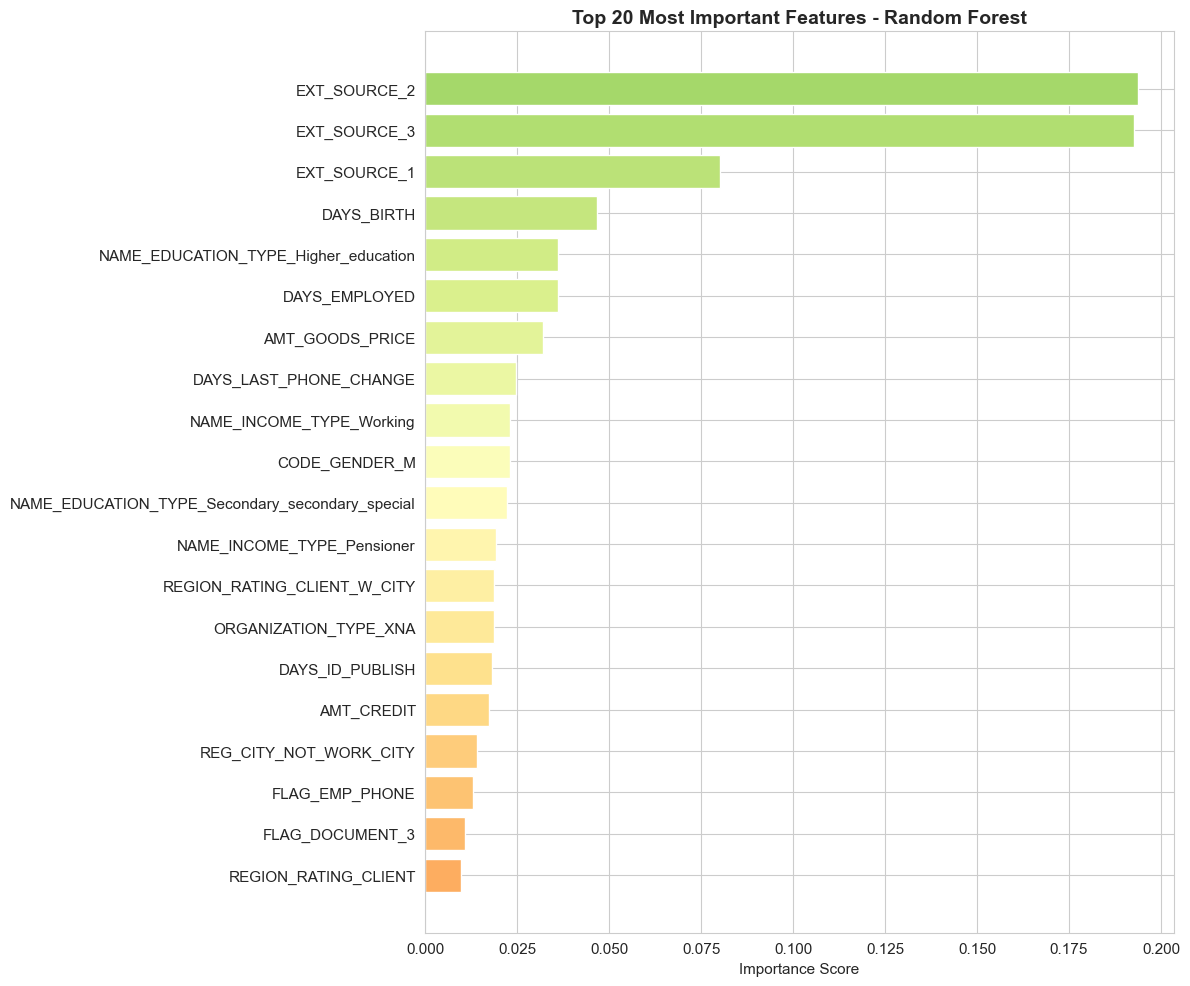

✓ Feature importance visualization generated


In [78]:
# Visualize top 20 features
fig, ax = plt.subplots(figsize=(12, 10))

top_20_features = feature_importance.head(20)
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, len(top_20_features)))

ax.barh(range(len(top_20_features)), top_20_features['Importance'].values, color=colors)
ax.set_yticks(range(len(top_20_features)))
ax.set_yticklabels(top_20_features['Feature'].values)
ax.set_xlabel('Importance Score')
ax.set_title('Top 20 Most Important Features - Random Forest', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("✓ Feature importance visualization generated")

## SHAP For RF

In [79]:
# Create SHAP explainer for the tuned Random Forest model
# Use TreeExplainer which is optimized for tree-based models
# Use a sample for faster computation
sample_size = min(5000, X_train.shape[0])
X_train_sample = X_train.sample(n=sample_size, random_state=42)

print(f"Creating SHAP TreeExplainer with {sample_size} background samples...")
print("(This may take a few moments)...")
explainer = shap.TreeExplainer(rf_model)
print("✓ SHAP explainer created successfully")

Creating SHAP TreeExplainer with 5000 background samples...
(This may take a few moments)...
✓ SHAP explainer created successfully


In [80]:
# Calculate SHAP values for the test set
print("Calculating SHAP values for test set (this may take a minute or two)...")
shap_values_test = explainer.shap_values(X_test)
print("✓ SHAP values calculated successfully")

# For binary classification, shap_values is a list with shape [2]
# We typically focus on class 1 (default)
# shap_values_test = shap_values_test[1]

print(f"\nSHAP values shape: {shap_values_test.shape}")
print(f"Expected shape (test samples × features): {X_test.shape}")

Calculating SHAP values for test set (this may take a minute or two)...
✓ SHAP values calculated successfully

SHAP values shape: (61503, 228, 2)
Expected shape (test samples × features): (61503, 228)


In [81]:
# Reshape SHAP values from (61503, 228, 2) to (61503, 228)
# Option 1: Take only class 1 (default prediction)
shap_values_test_reshaped = shap_values_test[:, :, 1]  # Shape: (61503, 228)

# Alternative options:
# Option 2: Take only class 0 (repay prediction)
# shap_values_test_reshaped = shap_values_test[:, :, 0]

# Option 3: Average SHAP values across both classes
# shap_values_test_reshaped = shap_values_test.mean(axis=2)

# Option 4: Sum SHAP values across both classes
# shap_values_test_reshaped = shap_values_test.sum(axis=2)

print(f"Original SHAP values shape: {shap_values_test.shape}")
print(f"Reshaped SHAP values shape: {shap_values_test_reshaped.shape}")
print("✓ SHAP values reshaped successfully")

Original SHAP values shape: (61503, 228, 2)
Reshaped SHAP values shape: (61503, 228)
✓ SHAP values reshaped successfully


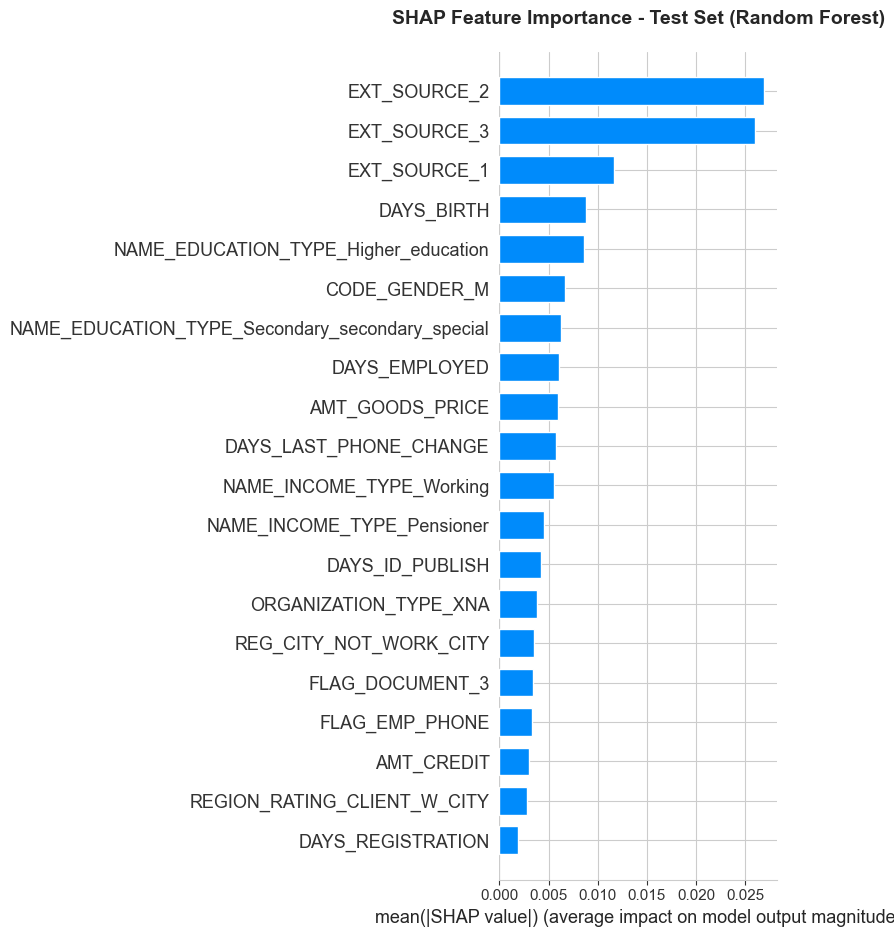

✓ SHAP summary plot (bar) generated


In [82]:
# SHAP Summary Plot (Bar) - shows feature importance based on SHAP values
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_test_reshaped, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Test Set (Random Forest)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ SHAP summary plot (bar) generated")

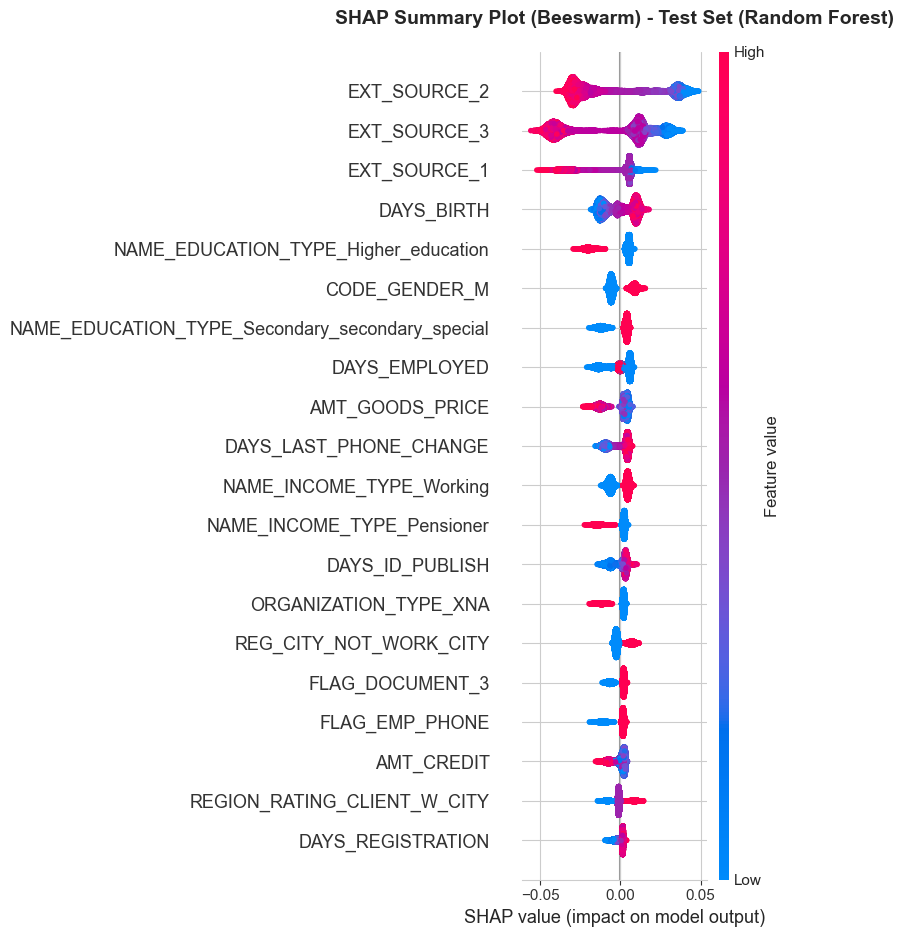

✓ SHAP summary plot (beeswarm) generated


In [83]:
# SHAP Summary Plot (Beeswarm) - shows the impact of each feature on model output
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_test_reshaped, X_test, show=False)
plt.title('SHAP Summary Plot (Beeswarm) - Test Set (Random Forest)', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ SHAP summary plot (beeswarm) generated")

In [84]:
# Analyze SHAP values - top features by mean absolute SHAP value
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_test_reshaped).mean(axis=0)
})
shap_importance = shap_importance.sort_values('Mean_Abs_SHAP', ascending=False)

print("Top 15 Most Important Features (by Mean Absolute SHAP values):")
print(shap_importance.head(15).to_string(index=False))

Top 15 Most Important Features (by Mean Absolute SHAP values):
                                        Feature  Mean_Abs_SHAP
                                   EXT_SOURCE_2       0.026888
                                   EXT_SOURCE_3       0.025987
                                   EXT_SOURCE_1       0.011688
                                     DAYS_BIRTH       0.008835
           NAME_EDUCATION_TYPE_Higher_education       0.008638
                                  CODE_GENDER_M       0.006691
NAME_EDUCATION_TYPE_Secondary_secondary_special       0.006217
                                  DAYS_EMPLOYED       0.006072
                                AMT_GOODS_PRICE       0.005930
                         DAYS_LAST_PHONE_CHANGE       0.005718
                       NAME_INCOME_TYPE_Working       0.005515
                     NAME_INCOME_TYPE_Pensioner       0.004494
                                DAYS_ID_PUBLISH       0.004228
                          ORGANIZATION_TYPE_XNA       0

# LIGHT GBM Model

In [91]:
# Initialize and train LightGBM model
print("Training LightGBM model (this may take a few minutes)...")
start_time = time.time()

lgb_model = lgb.LGBMClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    num_leaves=20,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_model.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f"\n✓ LightGBM model trained successfully in {elapsed_time:.2f} seconds")
print(f"\nModel parameters:")
print(f"  - Number of trees: {lgb_model.n_estimators}")
print(f"  - Max depth: {lgb_model.max_depth}")
print(f"  - Learning rate: {lgb_model.learning_rate}")
print(f"  - Number of leaves: {lgb_model.num_leaves}")
print(f"  - Number of features: {lgb_model.n_features_in_}")
print(f"  - Classes: {lgb_model.classes_}")

Training LightGBM model (this may take a few minutes)...

✓ LightGBM model trained successfully in 5.68 seconds

Model parameters:
  - Number of trees: 100
  - Max depth: 8
  - Learning rate: 0.1
  - Number of leaves: 20
  - Number of features: 228
  - Classes: [0 1]


In [92]:
# Make predictions on training and testing sets
y_train_pred = lgb_model.predict(X_train)
y_test_pred = lgb_model.predict(X_test)

# Get prediction probabilities
y_train_pred_proba = lgb_model.predict_proba(X_train)[:, 1]
y_test_pred_proba = lgb_model.predict_proba(X_test)[:, 1]

print("✓ Predictions generated for both training and testing sets")
print(f"\nTraining predictions distribution:")
print(pd.Series(y_train_pred).value_counts())
print(f"\nTesting predictions distribution:")
print(pd.Series(y_test_pred).value_counts())


✓ Predictions generated for both training and testing sets

Training predictions distribution:
0    164784
1     81224
Name: count, dtype: int64

Testing predictions distribution:
0    41286
1    20217
Name: count, dtype: int64


In [93]:
# Evaluate model performance on test set
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
roc_auc_test = roc_auc_score(y_test, y_test_pred_proba)

print("=" * 70)
print("MODEL PERFORMANCE METRICS (TEST SET)")
print("=" * 70)
print(f"Accuracy:   {accuracy_test:.4f}")
print(f"Precision:  {precision_test:.4f}")
print(f"Recall:     {recall_test:.4f}")
print(f"F1-Score:   {f1_test:.4f}")
print(f"ROC-AUC:    {roc_auc_test:.4f}")
print("=" * 70)

# Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(cm_test)

# Classification Report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Repay (0)', 'Default (1)']))

MODEL PERFORMANCE METRICS (TEST SET)
Accuracy:   0.7009
Precision:  0.1679
Recall:     0.6836
F1-Score:   0.2696
ROC-AUC:    0.7588

Confusion Matrix:
[[39715 16823]
 [ 1571  3394]]

Detailed Classification Report:
              precision    recall  f1-score   support

   Repay (0)       0.96      0.70      0.81     56538
 Default (1)       0.17      0.68      0.27      4965

    accuracy                           0.70     61503
   macro avg       0.56      0.69      0.54     61503
weighted avg       0.90      0.70      0.77     61503



In [94]:
# Compare training vs test performance
print("\n" + "=" * 70)
print("TRAINING vs TEST SET COMPARISON")
print("=" * 70)

metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Training Set': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        roc_auc_score(y_train, y_train_pred_proba)
    ],
    'Testing Set': [accuracy_test, precision_test, recall_test, f1_test, roc_auc_test]
})

metrics_comparison['Difference'] = metrics_comparison['Training Set'] - metrics_comparison['Testing Set']
print(metrics_comparison.to_string(index=False))


TRAINING vs TEST SET COMPARISON
   Metric  Training Set  Testing Set  Difference
 Accuracy      0.703497     0.700925    0.002572
Precision      0.173237     0.167879    0.005358
   Recall      0.708510     0.683585    0.024924
 F1-Score      0.278402     0.269558    0.008845
  ROC-AUC      0.780506     0.758752    0.021754


## Feature Importance for LGBM

In [95]:
# Extract feature importances from LightGBM
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgb_model.feature_importances_
})

# Sort by importance value
feature_importance = feature_importance.sort_values('Importance', ascending=False)

print("Top 20 Most Important Features (by Gain):")
print(feature_importance.head(20).to_string(index=False))


Top 20 Most Important Features (by Gain):
                             Feature  Importance
                        EXT_SOURCE_1         165
                        EXT_SOURCE_3         157
                        EXT_SOURCE_2         137
                          AMT_CREDIT         131
                          DAYS_BIRTH         113
                         AMT_ANNUITY         101
                     AMT_GOODS_PRICE          80
                       DAYS_EMPLOYED          78
                     DAYS_ID_PUBLISH          70
                   DAYS_REGISTRATION          44
              DAYS_LAST_PHONE_CHANGE          44
                       CODE_GENDER_M          41
  NAME_CONTRACT_TYPE_Revolving_loans          28
NAME_EDUCATION_TYPE_Higher_education          28
                      FLAG_OWN_CAR_Y          23
           AMT_REQ_CREDIT_BUREAU_QRT          22
                    AMT_INCOME_TOTAL          22
                         OWN_CAR_AGE          22
          AMT_REQ_CREDIT_BU

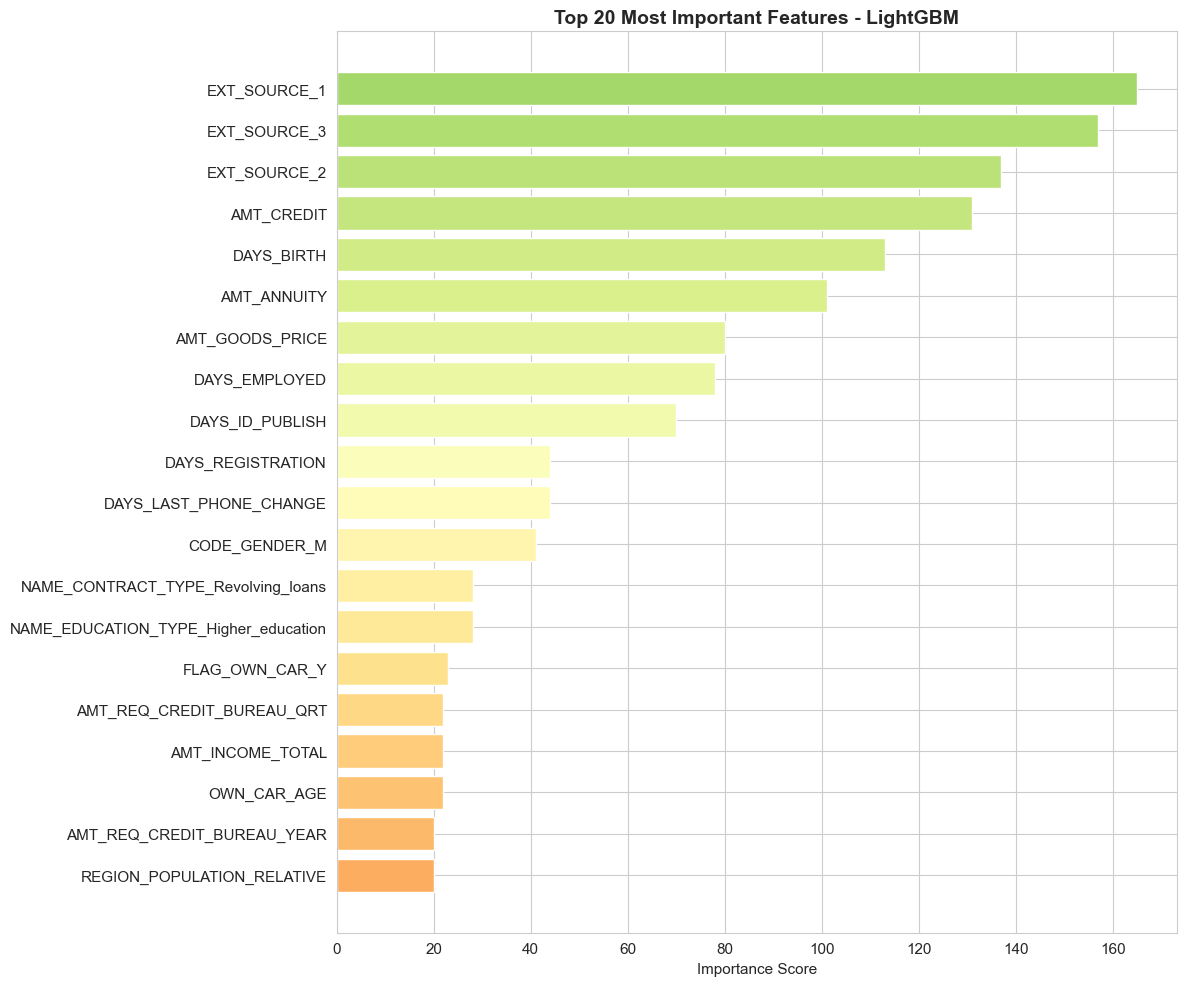

✓ Feature importance visualization generated


In [96]:
# Visualize top 20 features
fig, ax = plt.subplots(figsize=(12, 10))

top_20_features = feature_importance.head(20)
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, len(top_20_features)))

ax.barh(range(len(top_20_features)), top_20_features['Importance'].values, color=colors)
ax.set_yticks(range(len(top_20_features)))
ax.set_yticklabels(top_20_features['Feature'].values)
ax.set_xlabel('Importance Score')
ax.set_title('Top 20 Most Important Features - LightGBM', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("✓ Feature importance visualization generated")


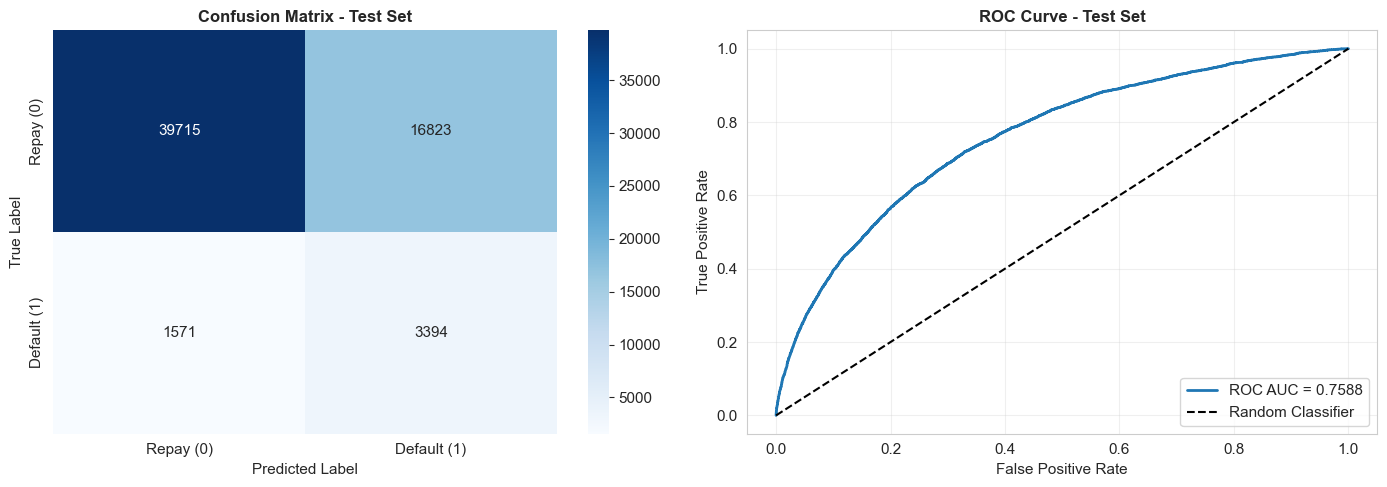

In [97]:
# Visualize Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Repay (0)', 'Default (1)'],
            yticklabels=['Repay (0)', 'Default (1)'])
axes[0].set_title('Confusion Matrix - Test Set', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc_test:.4f}', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Test Set', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## SHAP values for LGBM

In [98]:
# Create SHAP explainer for LightGBM model
# Use TreeExplainer which is optimized for tree-based models
sample_size = min(5000, X_train.shape[0])
X_train_sample = X_train.sample(n=sample_size, random_state=42)

print(f"Creating SHAP TreeExplainer with {sample_size} background samples...")
print("(This may take a few moments)...")
explainer = shap.TreeExplainer(lgb_model)
print("✓ SHAP explainer created successfully")

Creating SHAP TreeExplainer with 5000 background samples...
(This may take a few moments)...
✓ SHAP explainer created successfully


In [ ]:
# Calculate SHAP values for the test set
print("Calculating SHAP values for test set (this may take a moment)...")
shap_values_test = explainer.shap_values(X_test)
print("✓ SHAP values calculated successfully")

print(f"\nSHAP values shape: {shap_values_test.shape}")
print(f"Expected shape (test samples × features): {X_test.shape}")


Calculating SHAP values for test set (this may take a moment)...
✓ SHAP values calculated successfully

SHAP values shape: (61503, 228)
Expected shape (test samples × features): (61503, 228)


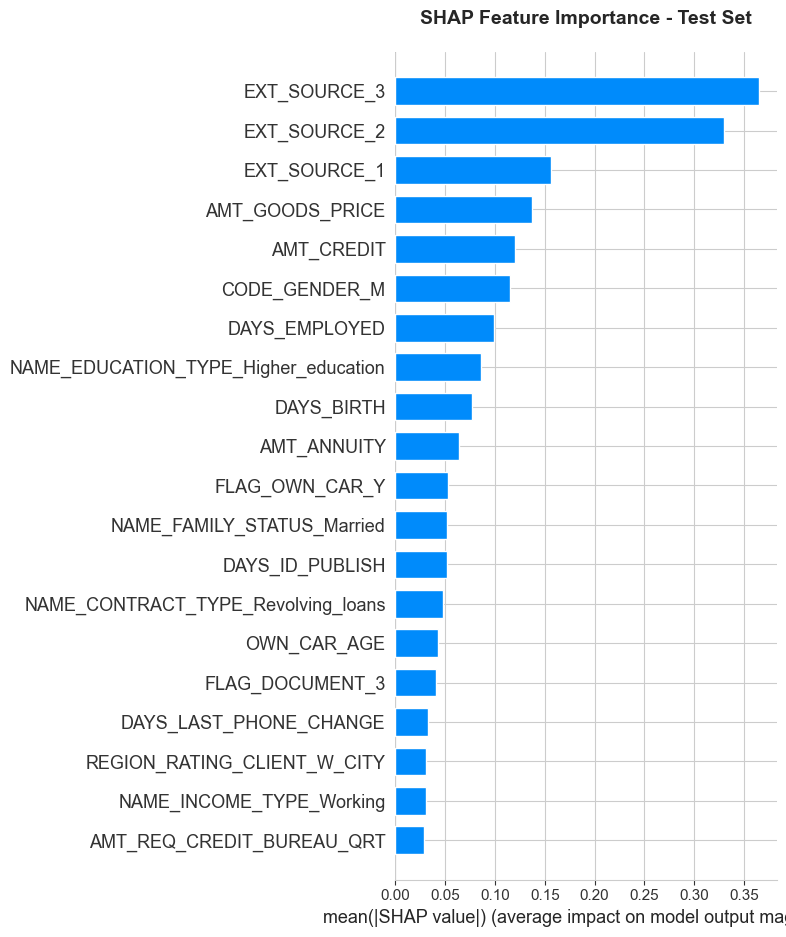

✓ SHAP summary plot (bar) generated


In [102]:
# SHAP Summary Plot (Bar) - shows feature importance based on SHAP values
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_test, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Test Set', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ SHAP summary plot (bar) generated")

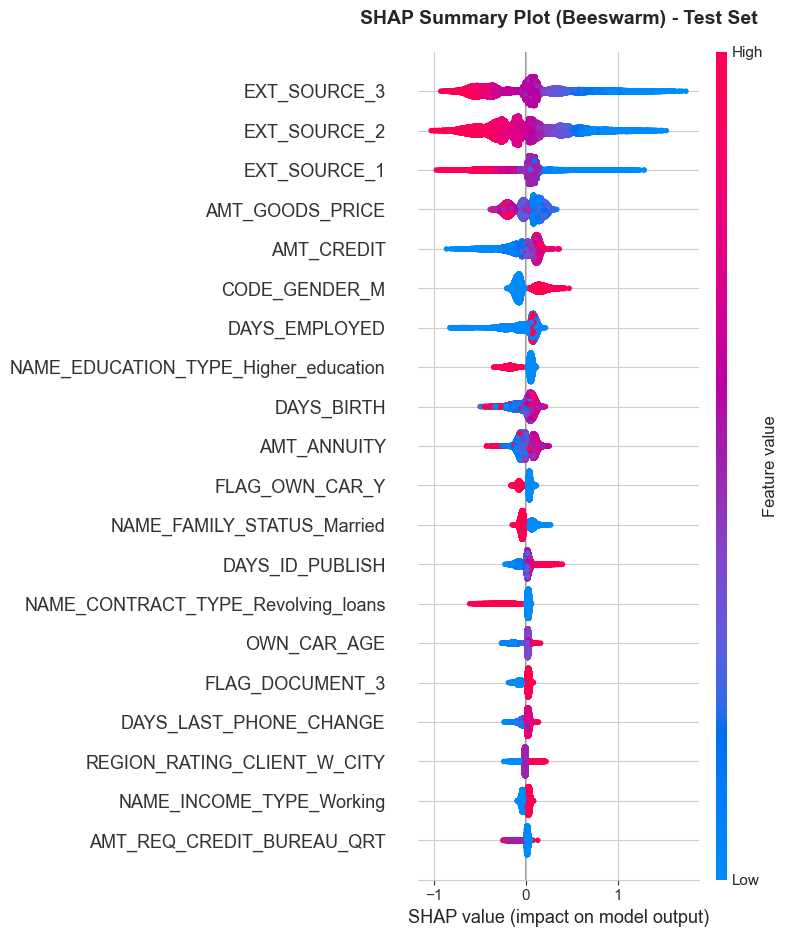

✓ SHAP summary plot (beeswarm) generated


In [103]:
# SHAP Summary Plot (Beeswarm) - shows the impact of each feature on model output
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_test, X_test, show=False)
plt.title('SHAP Summary Plot (Beeswarm) - Test Set', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ SHAP summary plot (beeswarm) generated")

In [104]:
# Analyze SHAP values - top features
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_test).mean(axis=0)
})
shap_importance = shap_importance.sort_values('Mean_Abs_SHAP', ascending=False)

print("Top 15 Most Important Features (by Mean Absolute SHAP values):")
print(shap_importance.head(15).to_string(index=False))

Top 15 Most Important Features (by Mean Absolute SHAP values):
                             Feature  Mean_Abs_SHAP
                        EXT_SOURCE_3       0.365077
                        EXT_SOURCE_2       0.329645
                        EXT_SOURCE_1       0.155825
                     AMT_GOODS_PRICE       0.136714
                          AMT_CREDIT       0.120083
                       CODE_GENDER_M       0.115509
                       DAYS_EMPLOYED       0.098656
NAME_EDUCATION_TYPE_Higher_education       0.085531
                          DAYS_BIRTH       0.077211
                         AMT_ANNUITY       0.064271
                      FLAG_OWN_CAR_Y       0.053049
          NAME_FAMILY_STATUS_Married       0.052253
                     DAYS_ID_PUBLISH       0.051791
  NAME_CONTRACT_TYPE_Revolving_loans       0.047472
                         OWN_CAR_AGE       0.042599


# XGBoost Model

In [112]:
# Calculate scale_pos_weight for imbalanced classes
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Initialize and train XGBoost model
print("\nTraining XGBoost model (this may take a few minutes)...")
start_time = time.time()

xgb_model = xgb.XGBClassifier(
    n_estimators=90,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)

elapsed_time = time.time() - start_time
print(f"\n\u2713 XGBoost model trained successfully in {elapsed_time:.2f} seconds")
print(f"\nModel parameters:")
print(f"  - Number of trees: {xgb_model.n_estimators}")
print(f"  - Max depth: {xgb_model.max_depth}")
print(f"  - Learning rate: {xgb_model.learning_rate}")
print(f"  - scale_pos_weight: {scale_pos_weight:.2f}")
print(f"  - Number of features: {xgb_model.n_features_in_}")

scale_pos_weight: 11.39

Training XGBoost model (this may take a few minutes)...

✓ XGBoost model trained successfully in 7.96 seconds

Model parameters:
  - Number of trees: 90
  - Max depth: 5
  - Learning rate: 0.1
  - scale_pos_weight: 11.39
  - Number of features: 228


In [113]:
# Make predictions on training and testing sets
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# Get prediction probabilities
y_train_pred_proba = xgb_model.predict_proba(X_train)[:, 1]
y_test_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("\u2713 Predictions generated for both training and testing sets")
print(f"\nTraining predictions distribution:")
print(pd.Series(y_train_pred).value_counts())
print(f"\nTesting predictions distribution:")
print(pd.Series(y_test_pred).value_counts())

✓ Predictions generated for both training and testing sets

Training predictions distribution:
0    165281
1     80727
Name: count, dtype: int64

Testing predictions distribution:
0    41387
1    20116
Name: count, dtype: int64


In [114]:
# Evaluate model performance on test set
accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)
roc_auc_test = roc_auc_score(y_test, y_test_pred_proba)

print("=" * 70)
print("XGBOOST MODEL PERFORMANCE METRICS (TEST SET)")
print("=" * 70)
print(f"Accuracy:   {accuracy_test:.4f}")
print(f"Precision:  {precision_test:.4f}")
print(f"Recall:     {recall_test:.4f}")
print(f"F1-Score:   {f1_test:.4f}")
print(f"ROC-AUC:    {roc_auc_test:.4f}")
print("=" * 70)

# Confusion Matrix
cm_test = confusion_matrix(y_test, y_test_pred)
print(f"\nConfusion Matrix:")
print(cm_test)

# Classification Report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Repay (0)', 'Default (1)']))

XGBOOST MODEL PERFORMANCE METRICS (TEST SET)
Accuracy:   0.7017
Precision:  0.1673
Recall:     0.6779
F1-Score:   0.2684
ROC-AUC:    0.7563

Confusion Matrix:
[[39788 16750]
 [ 1599  3366]]

Detailed Classification Report:
              precision    recall  f1-score   support

   Repay (0)       0.96      0.70      0.81     56538
 Default (1)       0.17      0.68      0.27      4965

    accuracy                           0.70     61503
   macro avg       0.56      0.69      0.54     61503
weighted avg       0.90      0.70      0.77     61503



In [115]:
# Compare training vs test performance
print("\n" + "=" * 70)
print("TRAINING vs TEST SET COMPARISON")
print("=" * 70)

metrics_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Training Set': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        roc_auc_score(y_train, y_train_pred_proba)
    ],
    'Testing Set': [accuracy_test, precision_test, recall_test, f1_test, roc_auc_test]
})

metrics_comparison['Difference'] = metrics_comparison['Training Set'] - metrics_comparison['Testing Set']
print(metrics_comparison.to_string(index=False))


TRAINING vs TEST SET COMPARISON
   Metric  Training Set  Testing Set  Difference
 Accuracy      0.706306     0.701657    0.004649
Precision      0.175505     0.167329    0.008176
   Recall      0.713394     0.677946    0.035448
 F1-Score      0.281706     0.268410    0.013296
  ROC-AUC      0.783499     0.756273    0.027226


## Feature Importance For XGBoost

In [116]:
# Extract feature importances from XGBoost
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
})

# Sort by importance value
feature_importance = feature_importance.sort_values('Importance', ascending=False)

print("Top 20 Most Important Features (by Gain):")
print(feature_importance.head(20).to_string(index=False))

Top 20 Most Important Features (by Gain):
                                        Feature  Importance
                                   EXT_SOURCE_3    0.057849
                                   EXT_SOURCE_2    0.056473
           NAME_EDUCATION_TYPE_Higher_education    0.030803
                       NAME_INCOME_TYPE_Working    0.029295
                                  CODE_GENDER_M    0.024904
                     NAME_INCOME_TYPE_Pensioner    0.023093
                                   EXT_SOURCE_1    0.018661
                                FLAG_DOCUMENT_3    0.017564
                                 FLAG_EMP_PHONE    0.013748
                                AMT_GOODS_PRICE    0.013071
                                 FLAG_OWN_CAR_Y    0.012857
                    REGION_RATING_CLIENT_W_CITY    0.012569
             NAME_CONTRACT_TYPE_Revolving_loans    0.011455
NAME_EDUCATION_TYPE_Secondary_secondary_special    0.011293
                       DEF_60_CNT_SOCIAL_CIRCLE    0.01111

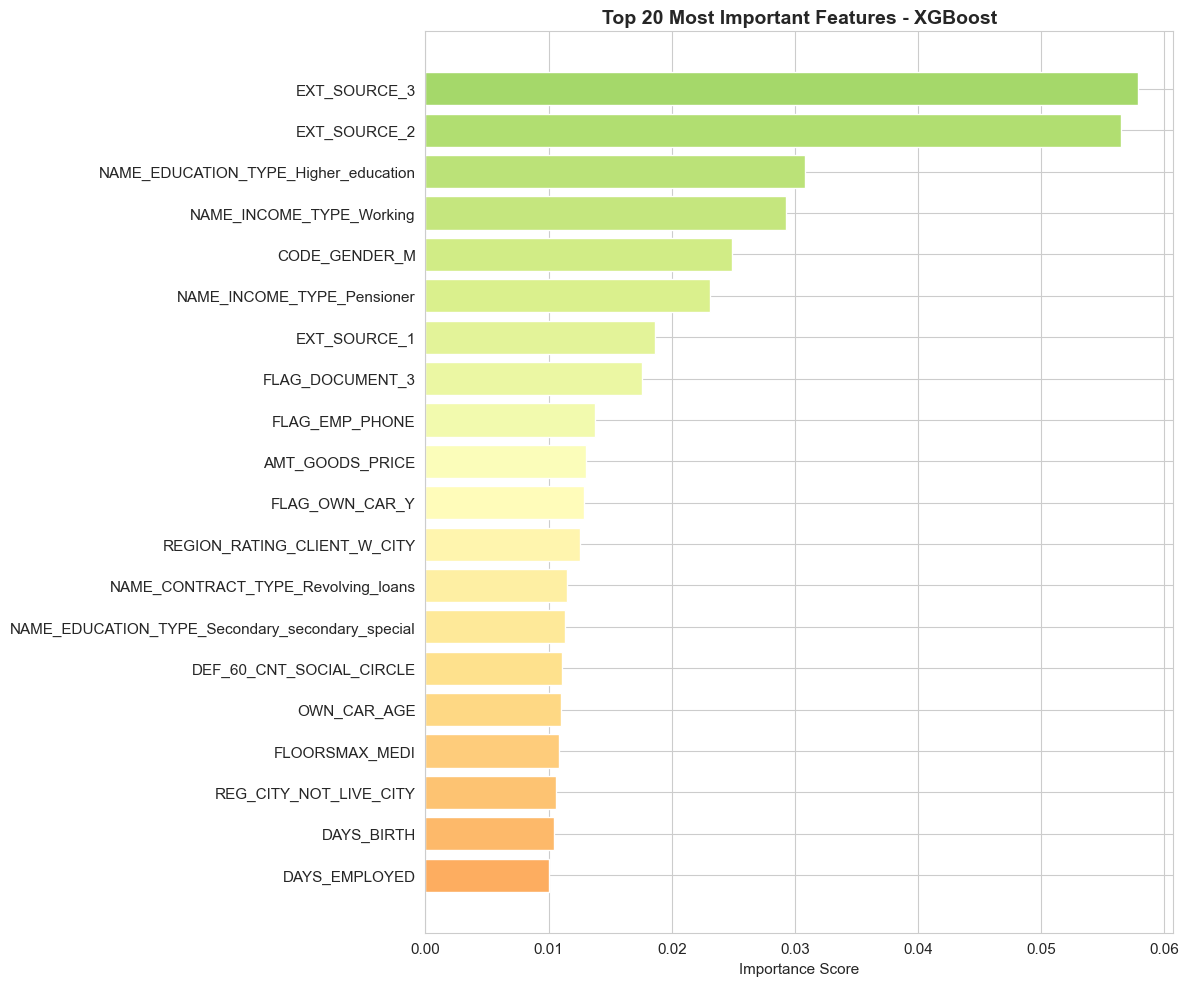

✓ Feature importance visualization generated


In [117]:
# Visualize top 20 features
fig, ax = plt.subplots(figsize=(12, 10))

top_20_features = feature_importance.head(20)
colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.7, len(top_20_features)))

ax.barh(range(len(top_20_features)), top_20_features['Importance'].values, color=colors)
ax.set_yticks(range(len(top_20_features)))
ax.set_yticklabels(top_20_features['Feature'].values)
ax.set_xlabel('Importance Score')
ax.set_title('Top 20 Most Important Features - XGBoost', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("\u2713 Feature importance visualization generated")

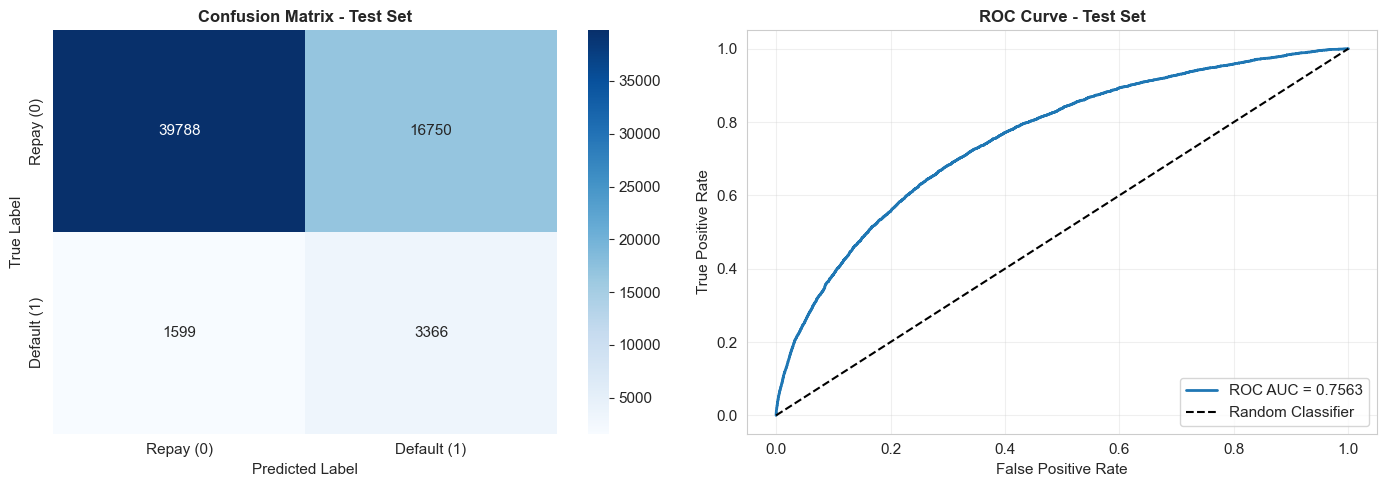

In [118]:
# Visualize Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Heatmap
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Repay (0)', 'Default (1)'],
            yticklabels=['Repay (0)', 'Default (1)'])
axes[0].set_title('Confusion Matrix - Test Set', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba)
axes[1].plot(fpr, tpr, label=f'ROC AUC = {roc_auc_test:.4f}', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve - Test Set', fontsize=12, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## SHAP Values for XGBoost

In [119]:
# Create SHAP explainer for XGBoost model
# Use TreeExplainer which is optimized for tree-based models
print("Creating SHAP TreeExplainer for XGBoost...")
print("(This may take a few moments)...")
explainer = shap.TreeExplainer(xgb_model)
print("\u2713 SHAP explainer created successfully")

Creating SHAP TreeExplainer for XGBoost...
(This may take a few moments)...
✓ SHAP explainer created successfully


In [120]:
# Calculate SHAP values for the test set
print("Calculating SHAP values for test set (this may take a minute or two)...")
shap_values_test = explainer.shap_values(X_test)
print("\u2713 SHAP values calculated successfully")

print(f"\nSHAP values shape: {shap_values_test.shape}")
print(f"Expected shape (test samples \u00d7 features): {X_test.shape}")

Calculating SHAP values for test set (this may take a minute or two)...
✓ SHAP values calculated successfully

SHAP values shape: (61503, 228)
Expected shape (test samples × features): (61503, 228)


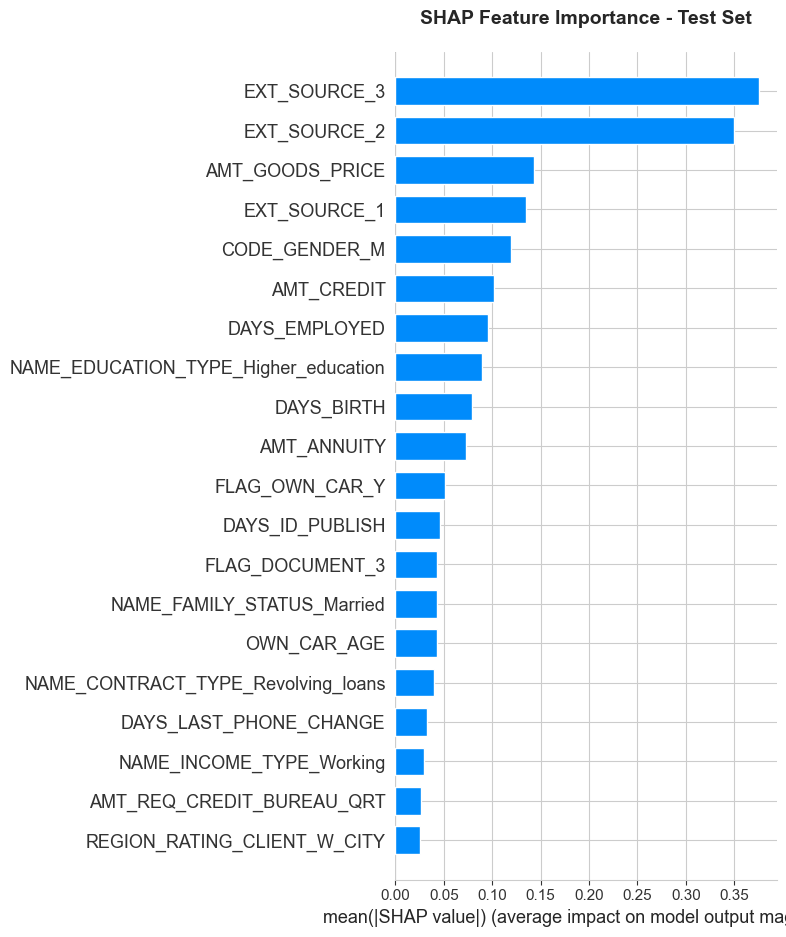

✓ SHAP summary plot (bar) generated


In [121]:
# SHAP Summary Plot (Bar) - shows feature importance based on SHAP values
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_test, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance - Test Set', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ SHAP summary plot (bar) generated")

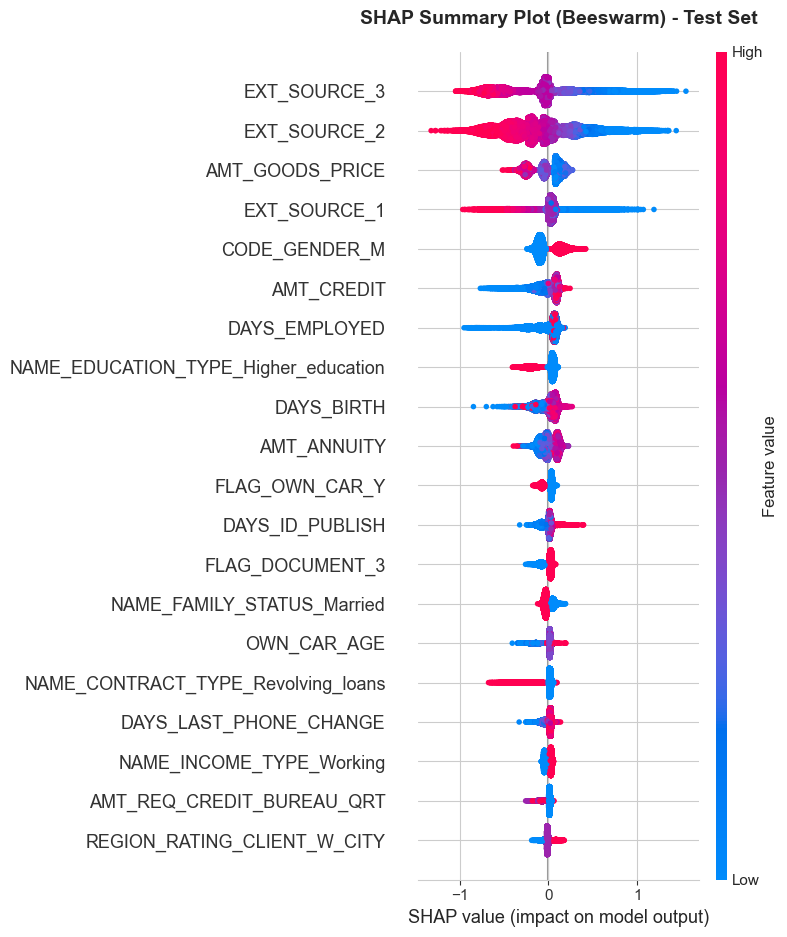

✓ SHAP summary plot (beeswarm) generated


In [122]:
# SHAP Summary Plot (Beeswarm) - shows the impact of each feature on model output
plt.figure(figsize=(12, 10))
shap.summary_plot(shap_values_test, X_test, show=False)
plt.title('SHAP Summary Plot (Beeswarm) - Test Set', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("✓ SHAP summary plot (beeswarm) generated")

In [123]:
# Analyze SHAP values - top features
shap_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean_Abs_SHAP': np.abs(shap_values_test).mean(axis=0)
})
shap_importance = shap_importance.sort_values('Mean_Abs_SHAP', ascending=False)

print("Top 15 Most Important Features (by Mean Absolute SHAP values):")
print(shap_importance.head(15).to_string(index=False))

Top 15 Most Important Features (by Mean Absolute SHAP values):
                             Feature  Mean_Abs_SHAP
                        EXT_SOURCE_3       0.375362
                        EXT_SOURCE_2       0.349344
                     AMT_GOODS_PRICE       0.143079
                        EXT_SOURCE_1       0.134939
                       CODE_GENDER_M       0.119158
                          AMT_CREDIT       0.101681
                       DAYS_EMPLOYED       0.095509
NAME_EDUCATION_TYPE_Higher_education       0.089022
                          DAYS_BIRTH       0.079177
                         AMT_ANNUITY       0.072457
                      FLAG_OWN_CAR_Y       0.051361
                     DAYS_ID_PUBLISH       0.046436
                     FLAG_DOCUMENT_3       0.043261
          NAME_FAMILY_STATUS_Married       0.043199
                         OWN_CAR_AGE       0.042548


# Fairness Analysis using Fairlearn

Evaluate model fairness across sensitive attributes (e.g., Gender) using Fairlearn metrics.


In [ ]:
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference
from fairlearn.metrics import demographic_parity_ratio, equalized_odds_ratio

# Reload original data to get sensitive attributes
df_original = pd.read_csv("../dataset/application_train.csv", encoding="latin-1")

# Extract sensitive attribute for test set using indices
# CODE_GENDER is a common sensitive attribute in credit risk
sensitive_feature = df_original.loc[X_test.index, 'CODE_GENDER'].values

print(f"Sensitive attribute: CODE_GENDER")
print(f"Distribution in test set:")
print(pd.Series(sensitive_feature).value_counts())
print(f"\nUnique values: {np.unique(sensitive_feature)}")


   ---------------------------------------- 0.0/41.0 MB ? eta -:--:--
   - -------------------------------------- 1.8/41.0 MB 9.7 MB/s eta 0:00:05
   ---- ----------------------------------- 4.2/41.0 MB 10.2 MB/s eta 0:00:04
   ----- ---------------------------------- 6.0/41.0 MB 9.8 MB/s eta 0:00:04
   ------- -------------------------------- 8.1/41.0 MB 9.7 MB/s eta 0:00:04
   ----------- ---------------------------- 11.3/41.0 MB 10.7 MB/s eta 0:00:03
   ------------ --------------------------- 12.8/41.0 MB 10.5 MB/s eta 0:00:03
   -------------- ------------------------- 14.4/41.0 MB 9.8 MB/s eta 0:00:03
   ---------------- ----------------------- 16.5/41.0 MB 9.8 MB/s eta 0:00:03
   ------------------ --------------------- 19.1/41.0 MB 10.1 MB/s eta 0:00:03
   -------------------- ------------------- 21.0/41.0 MB 10.0 MB/s eta 0:00:03
   ---------------------- ----------------- 23.3/41.0 MB 10.1 MB/s eta 0:00:02
   ------------------------ --------------- 24.9/41.0 MB 9.9 MB/s eta 

In [125]:
# Generate predictions from all models for fairness comparison
models = {
    'Logistic Regression': log_reg,
    'Random Forest': rf_model,
    'LightGBM': lgb_model,
    'XGBoost': xgb_model
}

# Store predictions for each model
model_predictions = {}
for name, model in models.items():
    model_predictions[name] = {
        'y_pred': model.predict(X_test),
        'y_pred_proba': model.predict_proba(X_test)[:, 1]
    }

print("✓ Predictions generated for all models")
for name in models:
    pred_dist = pd.Series(model_predictions[name]['y_pred']).value_counts()
    print(f"\n{name} - Test predictions: 0={pred_dist.get(0, 0)}, 1={pred_dist.get(1, 0)}")


[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished


✓ Predictions generated for all models

Logistic Regression - Test predictions: 0=40634, 1=20869

Random Forest - Test predictions: 0=39125, 1=22378

LightGBM - Test predictions: 0=41286, 1=20217

XGBoost - Test predictions: 0=41387, 1=20116


In [ ]:
# Fairness metrics for each model using MetricFrame
fairness_metrics = {
    'accuracy': accuracy_score,
    'precision': precision_score,
    'recall': recall_score,
    'f1_score': f1_score,
    'roc_auc': lambda y_true, y_pred: roc_auc_score(y_true, y_pred)
}

print("=" * 80)
print("FAIRNESS ANALYSIS BY GENDER (CODE_GENDER)")
print("=" * 80)

fairness_results = []

for model_name in models:
    y_pred = model_predictions[model_name]['y_pred']
    y_proba = model_predictions[model_name]['y_pred_proba']
    
    # MetricFrame for group-wise metrics
    mf = MetricFrame(
        metrics={
            'Accuracy': accuracy_score,
            'Precision': precision_score,
            'Recall': recall_score,
            'F1-Score': f1_score,
            'Selection Rate': lambda y_true, y_pred: np.mean(y_pred)
        },
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=sensitive_feature
    )
    
    print(f"\n{'─' * 80}")
    print(f"Model: {model_name}")
    print(f"{'─' * 80}")
    print(f"\nMetrics by group:")
    print(mf.by_group.to_string())
    print(f"\nDifference (max - min across groups):")
    print(mf.difference().to_string())
    
    # Demographic Parity Difference
    dpd = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_feature)
    
    # Equalized Odds Difference
    eod = equalized_odds_difference(y_test, y_pred, sensitive_features=sensitive_feature)
    
    # Demographic Parity Ratio
    dpr = demographic_parity_ratio(y_test, y_pred, sensitive_features=sensitive_feature)
    
    # Equalized Odds Ratio
    eor = equalized_odds_ratio(y_test, y_pred, sensitive_features=sensitive_feature)
    
    print(f"\nDemographic Parity Difference: {dpd:.4f}")
    print(f"Demographic Parity Ratio:      {dpr:.4f}")
    print(f"Equalized Odds Difference:     {eod:.4f}")
    print(f"Equalized Odds Ratio:          {eor:.4f}")
    
    fairness_results.append({
        'Model': model_name,
        'Demographic Parity Diff': dpd,
        'Demographic Parity Ratio': dpr,
        'Equalized Odds Diff': eod,
        'Equalized Odds Ratio': eor
    })

# Summary comparison
print(f"\n{'=' * 80}")
print("FAIRNESS COMPARISON ACROSS MODELS")
print(f"{'=' * 80}")
fairness_df = pd.DataFrame(fairness_results)
print(fairness_df.to_string(index=False))
print("\nNote: Values closer to 0 (difference) or 1 (ratio) indicate greater fairness.")


FAIRNESS ANALYSIS BY GENDER (CODE_GENDER)

────────────────────────────────────────────────────────────────────────────────
Model: Logistic Regression
────────────────────────────────────────────────────────────────────────────────

Metrics by group:
                     Accuracy  Precision    Recall  F1-Score  Selection Rate
sensitive_feature_0                                                         
F                    0.734868   0.152109  0.610367  0.243528        0.280565
M                    0.602006   0.173042  0.771254  0.282665        0.453152
XNA                  1.000000   0.000000  0.000000  0.000000        0.000000

Difference (max - min across groups):
Accuracy          0.397994
Precision         0.173042
Recall            0.771254
F1-Score          0.282665
Selection Rate    0.453152

Demographic Parity Difference: 0.4532
Demographic Parity Ratio:      0.0000
Equalized Odds Difference:     0.7713
Equalized Odds Ratio:          0.0000

────────────────────────────────────

In [ ]:
# Visualize fairness metrics across models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Demographic Parity Difference
axes[0].barh(fairness_df['Model'], fairness_df['Demographic Parity Diff'], color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
axes[0].set_xlabel('Demographic Parity Difference')
axes[0].set_title('Demographic Parity Difference by Model\n(closer to 0 = more fair)', fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='--', alpha=0.5)

# Equalized Odds Difference
axes[1].barh(fairness_df['Model'], fairness_df['Equalized Odds Diff'], color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
axes[1].set_xlabel('Equalized Odds Difference')
axes[1].set_title('Equalized Odds Difference by Model\n(closer to 0 = more fair)', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("✓ Fairness comparison visualization generated")


In [ ]:
# Detailed group-wise selection rate comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, (model_name, model) in enumerate(models.items()):
    y_pred = model_predictions[model_name]['y_pred']
    
    mf = MetricFrame(
        metrics={'Selection Rate': lambda y_true, y_pred: np.mean(y_pred)},
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=sensitive_feature
    )
    
    group_rates = mf.by_group['Selection Rate']
    bars = axes[idx].bar(group_rates.index, group_rates.values, color=['#4C72B0', '#DD8452', '#55A868'], alpha=0.8)
    axes[idx].set_title(f'{model_name}\nSelection Rate by Gender', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Selection Rate (predicted default)')
    axes[idx].set_ylim(0, max(group_rates.values) * 1.3)
    
    # Add value labels on bars
    for bar, val in zip(bars, group_rates.values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                      f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("✓ Group-wise selection rate comparison generated")
